<a href="https://colab.research.google.com/github/jinsyabeycg/BITS-AIML-Mtech-V2/blob/master/DRL_DP_Clinical_Trial_Assignment01_Group124.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Group ID: Group_124
###Group Members Name with Student ID:
##Nimishkumar Patel - 2024AA05225
##Jinsy Abey - 2024AA05223
##Sunil Pandey - 2024AA05222
##Ayan Deb - 2024AA05430

### The Smart Supplier: Optimizing Orders in a Fluctuating Market - 6 Marks

Develop a reinforcement learning agent using dynamic programming to help a Smart Supplier decide which products to manufacture and sell each day to maximize profit. The agent must learn the optimal policy for choosing daily production quantities, considering its limited raw materials and the unpredictable daily demand and selling prices for different products.

#### **Scenario**
 A small Smart Supplier manufactures two simple products: Product A and Product B. Each day, the supplier has a limited amount of raw material. The challenge is that the market demand and selling price for Product A and Product B change randomly each day, making some products more profitable than others at different times. The supplier needs to decide how much of each product to produce to maximize profit while managing their limited raw material.

#### **Objective**
The Smart Supplier's agent must learn the optimal policy π∗ using dynamic programming (Value Iteration or Policy Iteration) to decide how many units of Product A and Product B to produce each day to maximize the total profit over the fixed number of days, given the daily changing market conditions and limited raw material.

### --- 1. Custom Environment Creation (SmartSupplierEnv) --- ( 1 Mark )

In [ ]:
# Define market states and their product prices
# Structure: {Market_State_ID: {'A_price': X, 'B_price': Y}}
# Define product raw material costs
# Define actions: (num_A, num_B, raw_material_cost_precalculated)
        # Action ID mapping:
        # 0: Produce_2A_0B
        # 1: Produce_1A_2B
        # 2: Produce_0A_5B
        # 3: Produce_3A_0B
        # 4: Do_Nothing

 # Define state space dimensions
        # Current Day: 1 to num_days
        # Current Raw Material: 0 to initial_raw_material
        # Current Market State: 1 or 2

# get reward function
# Define market states and their product prices
MARKET_STATES = {
    1: {'A_price': 8, 'B_price': 2},  # High Demand for Product A
    2: {'A_price': 3, 'B_price': 5}   # High Demand for Product B
}

# Define actions as: (num_A, num_B, raw_material_cost)
ACTIONS = {
    0: (2, 0, 4),   # Produce 2A_0B → 2*2 = 4 RM
    1: (1, 2, 4),   # Produce 1A_2B → 2+2*1 = 4 RM
    2: (0, 5, 5),   # Produce 0A_5B → 5*1 = 5 RM
    3: (3, 0, 6),   # Produce 3A_0B → 3*2 = 6 RM
    4: (0, 0, 0),   # Do_Nothing
}

# Define state space dimensions
TOTAL_DAYS = 5
INITIAL_RM = 10

# States: (current_day, current_raw_material, current_market_state)
# Day: 1 to TOTAL_DAYS
# RM: 0 to INITIAL_RM
# Market: 1 or 2

# Reward Function
def get_reward(action_id, market_state):
    num_A, num_B, _ = ACTIONS[action_id]
    prices = MARKET_STATES[market_state]
    return num_A * prices['A_price'] + num_B * prices['B_price']

### --- 2. Dynamic Programming Implementation (Value Iteration or Policy Iteration) --- (2 Mark)

In [ ]:
# Value Iteration function

import numpy as np

GAMMA = 1.0     # No discounting
THETA = 1e-4    # Convergence threshold

# State space: (day, raw_material, market_state)
states = [(day, rm, ms) for day in range(1, TOTAL_DAYS+1)
                         for rm in range(INITIAL_RM+1)
                         for ms in [1, 2]]

# Value Iteration function
def value_iteration():
    V = {s: 0 for s in states}
    policy = {}
    iterations = 0

    while True:
        delta = 0
        for state in states:
            day, rm, ms = state
            if day > TOTAL_DAYS:
                continue

            best_val = float('-inf')
            best_action = None

            for a_id, (a, b, cost) in ACTIONS.items():
                if cost > rm:
                    continue  # skip invalid action

                reward = get_reward(a_id, ms)
                next_day = day + 1
                if next_day > TOTAL_DAYS:
                    future_val = 0
                else:
                    # Since market state is stochastic (50-50)
                    future_val = 0.5 * V[(next_day, INITIAL_RM, 1)] + 0.5 * V[(next_day, INITIAL_RM, 2)]

                total = reward + GAMMA * future_val
                if total > best_val:
                    best_val = total
                    best_action = a_id

            delta = max(delta, abs(V[state] - best_val))
            V[state] = best_val
            policy[state] = best_action

        iterations += 1
        if delta < THETA:
            break

    return V, policy, iterations

#### --- 3. Simulation and Policy Analysis ---  ( 1 Mark)

In [ ]:
# simulate policy function - Simulates the learned policy over multiple runs to evaluate performance

# analyze policy function - Analyzes and prints snippets of the learned optimal policy

import random

# Simulate learned policy over multiple runs
def simulate_policy(policy, runs=1000, seed=42):
    random.seed(seed)
    profits = []

    for _ in range(runs):
        total_profit = 0
        for day in range(1, TOTAL_DAYS + 1):
            market_state = random.choice([1, 2])  # Randomly switch market
            state = (day, INITIAL_RM, market_state)
            action = policy[state]
            reward = get_reward(action, market_state)
            total_profit += reward
        profits.append(total_profit)

    avg_profit = np.mean(profits)
    std_profit = np.std(profits)
    print(f"Simulated {runs} runs of 5-day episodes:")
    print(f"Average Total Profit: {avg_profit:.2f}")
    print(f"Standard Deviation : {std_profit:.2f}")
    return profits

# Analyze the learned policy structure
def analyze_policy(policy):
    print("Sample Optimal Policy (Day 1):")
    for rm in range(0, INITIAL_RM + 1):
        for ms in [1, 2]:
            state = (1, rm, ms)
            action = policy.get(state, None)
            if action is not None:
                print(f"  RM: {rm}, Market: {ms} → Action: {action} ({ACTIONS[action][:2]})")

#### --- 4. Impact of Dynamics Analysis --- (1 Mark)

In [ ]:
### Impact of Dynamics Analysis

#The dynamic nature of the market—where the price of Products A and B shifts randomly between two states—significantly influences the optimal production policy.

#In **Market State 1**, where Product A has a high reward (+8), the optimal policy tends to favor producing more of Product A, even though it consumes more raw material (2 RM/unit). Conversely, in **Market State 2**, Product B becomes more profitable (+5), and the agent adapts by preferring to produce more units of Product B, which is cheaper in RM usage (1 RM/unit).

#This **shift in strategy** depending on the market state demonstrates the agent's ability to exploit market opportunities while respecting resource constraints. If the market had **fixed prices** (e.g., always in State 1), the policy would become more **deterministic**, consistently favoring high-value Product A. But in the dynamic environment, the policy becomes more **adaptive**, balancing risk and reward based on market uncertainty.

#This highlights the value of dynamic programming in handling **non-stationary environments** where optimal actions depend not just on resource levels but also on external market dynamics.

In [ ]:
# --- Main Execution ---



In [ ]:

# Imports and Initial Constants
import numpy as np
import itertools
from collections import defaultdict
import matplotlib.pyplot as plt

# Environment Parameters
MAX_INVENTORY = 10
MAX_ORDER = 10
HOLDING_COST = 1.0
COST_PRICE = 5.0
SELL_PRICES = [8.0, 10.0, 12.0]
DEMAND_MEAN = [2.0, 5.0, 7.0]
TRANSITION_P = np.array([[0.6,0.3,0.1],[0.2,0.6,0.2],[0.1,0.3,0.6]])

DISCOUNT_GAMMA = 0.95
THETA = 1e-4
MAX_DEMAND_SIM = MAX_INVENTORY + MAX_ORDER


In [ ]:

# Demand Probability Mass Function
import math
DEMAND_PMF = {}

for m, lam in enumerate(DEMAND_MEAN):
    pmf = [np.exp(-lam) * lam**k / math.factorial(k) for k in range(MAX_DEMAND_SIM)]
    tail = 1.0 - sum(pmf)
    pmf.append(tail)
    DEMAND_PMF[m] = pmf


In [ ]:

# State and Action Definitions
states = list(itertools.product(range(MAX_INVENTORY + 1), range(len(SELL_PRICES))))
ACTIONS = list(range(MAX_ORDER + 1))


In [ ]:

# Reward Calculation Function
def expected_reward(next_inv, sold, order, m_state):
    revenue = sold * SELL_PRICES[m_state]
    cost = order * COST_PRICE + next_inv * HOLDING_COST
    return revenue - cost

# Environment Transition Function
def one_step_dynamics(state, action):
    inv, m = state
    order = min(action, MAX_INVENTORY - inv)
    pre_demand_stock = inv + order
    outcomes = []
    for d, p_d in enumerate(DEMAND_PMF[m]):
        sold = min(pre_demand_stock, d)
        next_inv = pre_demand_stock - sold
        r = expected_reward(next_inv, sold, order, m)
        for m_next, p_m in enumerate(TRANSITION_P[m]):
            prob = p_d * p_m
            next_state = (next_inv, m_next)
            outcomes.append((prob, next_state, r))
    return outcomes


In [ ]:

# Value Iteration
def value_iteration():
    V = defaultdict(float)
    iteration = 0
    while True:
        delta = 0.0
        for s in states:
            v_old = V[s]
            q_sa = []
            for a in ACTIONS:
                q = sum(prob * (r + DISCOUNT_GAMMA * V[s_next])
                        for prob, s_next, r in one_step_dynamics(s, a))
                q_sa.append(q)
            V[s] = max(q_sa)
            delta = max(delta, abs(v_old - V[s]))
        iteration += 1
        if delta < THETA:
            break
    policy = {}
    for s in states:
        q_sa = []
        for a in ACTIONS:
            q = sum(prob * (r + DISCOUNT_GAMMA * V[s_next])
                    for prob, s_next, r in one_step_dynamics(s, a))
            q_sa.append(q)
        policy[s] = int(np.argmax(q_sa))
    return V, policy, iteration


In [ ]:

# Policy Simulation
def simulate_episode(policy, seed=None, horizon=50):
    rng = np.random.default_rng(seed)
    inv = rng.integers(0, MAX_INVENTORY + 1)
    m = rng.integers(0, len(SELL_PRICES))
    total_reward = 0.0
    for _ in range(horizon):
        a = policy[(inv, m)]
        order = min(a, MAX_INVENTORY - inv)
        demand = min(rng.poisson(DEMAND_MEAN[m]), MAX_DEMAND_SIM)
        sold = min(inv + order, demand)
        next_inv = inv + order - sold
        total_reward += expected_reward(next_inv, sold, order, m)
        m = rng.choice(range(len(SELL_PRICES)), p=TRANSITION_P[m])
        inv = next_inv
    return total_reward


Running Value Iteration

Converged in 139 iterations (θ=0.0001)

Optimal order quantities when market state = 1:
Inventory 0 -> Order 7
Inventory 1 -> Order 6
Inventory 2 -> Order 5
Inventory 3 -> Order 4
Inventory 4 -> Order 3
Inventory 5 -> Order 2
Inventory 6 -> Order 1
Inventory 7 -> Order 0
Inventory 8 -> Order 0
Inventory 9 -> Order 0
Inventory 10 -> Order 0

----------------------------------------------
Evaluation over 1000 simulated 50-step episodes
Average total profit  : 1169.27
Std-dev of total profit: 207.96
----------------------------------------------


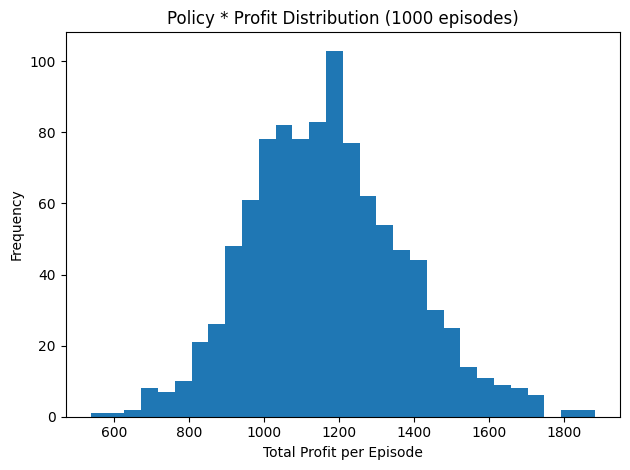

In [ ]:

# Run the full pipeline
if __name__ == "__main__":
    print("Running Value Iteration\n")
    V, policy, iters = value_iteration()
    print(f"Converged in {iters} iterations (θ={THETA})\n")

    print("Optimal order quantities when market state = 1:")
    for inv in range(MAX_INVENTORY + 1):
        print(f"Inventory {inv} -> Order {policy[(inv,1)]}")

    EPISODES = 1000
    rewards = [simulate_episode(policy, seed=i) for i in range(EPISODES)]

    print("\n----------------------------------------------")
    print(f"Evaluation over {EPISODES} simulated 50-step episodes")
    print(f"Average total profit  : {np.mean(rewards):.2f}")
    print(f"Std-dev of total profit: {np.std(rewards):.2f}")
    print("----------------------------------------------")

    plt.hist(rewards, bins=30)
    plt.xlabel("Total Profit per Episode")
    plt.ylabel("Frequency")
    plt.title("Policy * Profit Distribution (1000 episodes)")
    plt.tight_layout()
    plt.show()
